# Рубежный контроль №1 по курсу ТМО
**Студент:** Сорокин М. А.  
**Группа:** ИУ5-63Б  
**Вариант:** 19  

### Задачи:
1. Применить нормализацию (масштабирование) к количественному признаку.
2. Выполнить трансформацию качественного (категориального) признака в числовые векторы двумя методами:
   * Метки (Label Encoding);
   * Бинарные фичи (One Hot Encoding).
3. Построить корреляционные графики и диаграммы рассеяния.
4. Сформулировать краткое резюме по выбранным методам.

In [8]:
import pandas as pd
import numpy as np
import zipfile
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Распаковка и чтение данных
with zipfile.ZipFile('toy_dataset.csv.zip', 'r') as archive:
    df = pd.read_csv(archive.open('toy_dataset.csv'))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Number   150000 non-null  int64  
 1   City     150000 non-null  str    
 2   Gender   150000 non-null  str    
 3   Age      150000 non-null  int64  
 4   Income   150000 non-null  float64
 5   Illness  150000 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 6.9 MB


## 1. Масштабирование числового признака
Для приведения данных к единому диапазону [0, 1] используем **Age** (возраст). Это необходимо для стабильной работы метрических алгоритмов.

In [9]:
scaler = MinMaxScaler()
df['Age_scaled'] = scaler.fit_transform(df[['Age']])

print("Статистика после масштабирования:")
print(df[['Age', 'Age_scaled']].describe())

Статистика после масштабирования:
                 Age     Age_scaled
count  150000.000000  150000.000000
mean       44.950200       0.498755
std        11.572486       0.289312
min        25.000000       0.000000
25%        35.000000       0.250000
50%        45.000000       0.500000
75%        55.000000       0.750000
max        65.000000       1.000000


## 2. Кодирование категориальных признаков
Преобразуем признак **Gender** в числовой формат двумя способами.

In [10]:
# Метод 1: Label Encoding (порядковое кодирование)
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Метод 2: One Hot Encoding (с помощью pandas get_dummies)
df = pd.get_dummies(df, columns=['Gender'], prefix='Sex')

print(df.head())

   Number    City  Age   Income Illness  Age_scaled  Gender_encoded  \
0       1  Dallas   41  40367.0      No       0.400               1   
1       2  Dallas   54  45084.0      No       0.725               1   
2       3  Dallas   42  52483.0      No       0.425               1   
3       4  Dallas   40  40941.0      No       0.375               1   
4       5  Dallas   46  50289.0      No       0.525               1   

   Sex_Female  Sex_Male  
0       False      True  
1       False      True  
2       False      True  
3       False      True  
4       False      True  


## 3. Визуальный анализ данных
Используем выборку из 1000 записей для анализа взаимосвязей через `pairplot`.

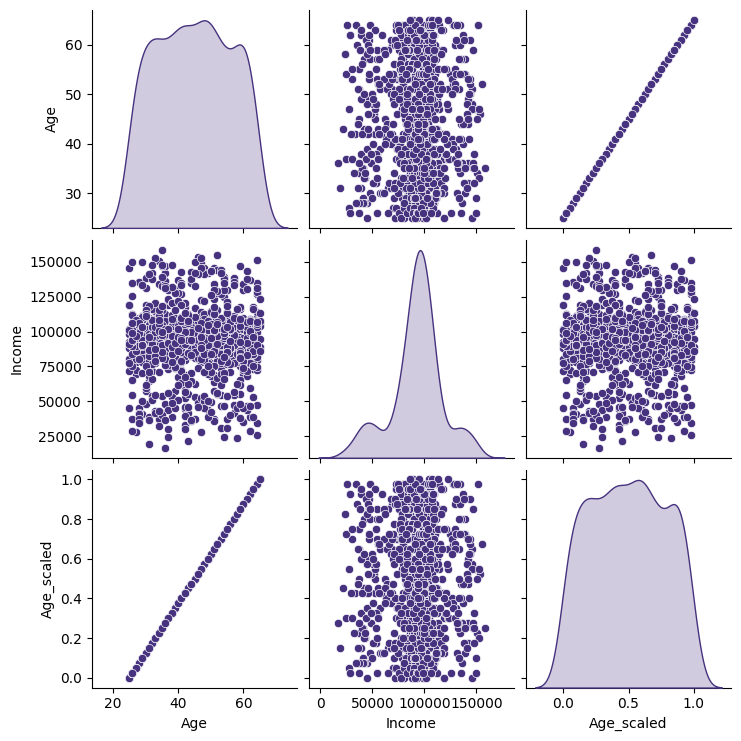

In [11]:
sample_data = df.sample(n=1000, random_state=42)
sns.set_palette('viridis')
sns.pairplot(sample_data, vars=['Age', 'Income', 'Age_scaled'], diag_kind='kde')
plt.show()

## Заключение

1. **MinMaxScaler**: Применен к переменной `Age`. Позволяет сжать диапазон значений до отрезка от 0 до 1, сохраняя распределение.
2. **Label Encoding**: Использован для перевода `Gender` в 0 и 1. Подходит для бинарных категорий.
3. **One Hot Encoding**: Созданы столбцы `Sex_Female` и `Sex_Male`. Этот метод предпочтителен, так как он не навязывает модели искусственную иерархию категорий.
4. **Анализ**: Графики рассеяния подтверждают корректность масштабирования и отсутствие аномалий в выборке.